ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

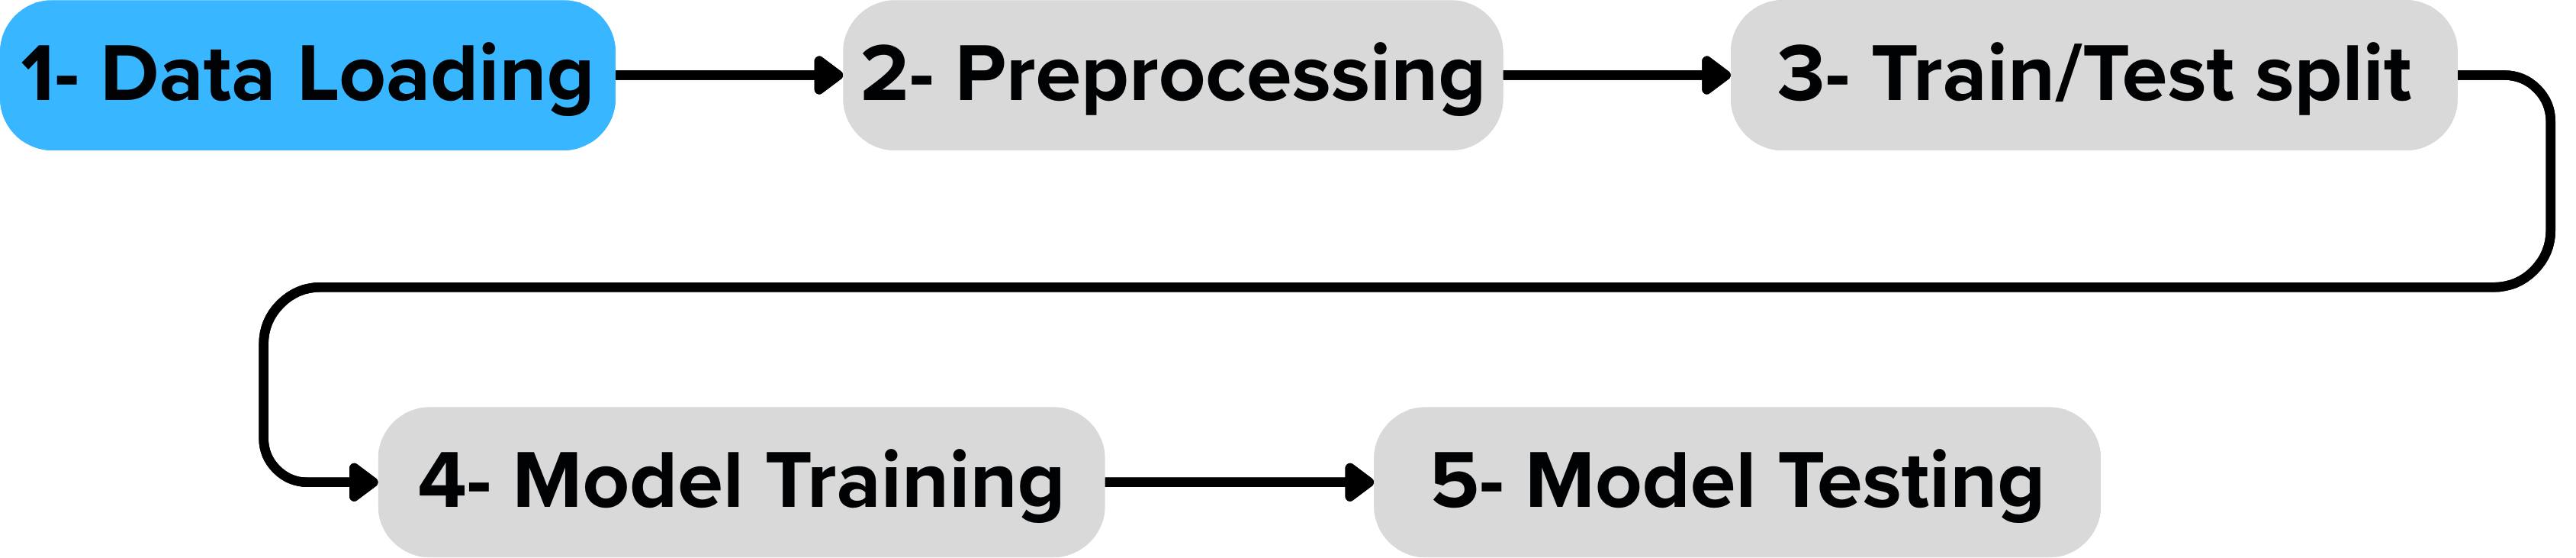

In [57]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [58]:
df = pd.read_csv('EVCarsSales.csv')

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      3798 non-null   object 
 1   category    3798 non-null   object 
 2   parameter   3798 non-null   object 
 3   mode        3798 non-null   object 
 4   powertrain  3798 non-null   object 
 5   year        3798 non-null   int64  
 6   unit        3798 non-null   object 
 7   value       3798 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 237.5+ KB


### Check Missing Values

In [60]:
# Check all values
print(df.isna())

#sum nan values
print(df.isna().sum())


      region  category  parameter   mode  powertrain   year   unit  value
0      False     False      False  False       False  False  False  False
1      False     False      False  False       False  False  False  False
2      False     False      False  False       False  False  False  False
3      False     False      False  False       False  False  False  False
4      False     False      False  False       False  False  False  False
...      ...       ...        ...    ...         ...    ...    ...    ...
3793   False     False      False  False       False  False  False  False
3794   False     False      False  False       False  False  False  False
3795   False     False      False  False       False  False  False  False
3796   False     False      False  False       False  False  False  False
3797   False     False      False  False       False  False  False  False

[3798 rows x 8 columns]
region        0
category      0
parameter     0
mode          0
powertrain    0
year   

### Check duplicate rows

In [61]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [62]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (3798, 8) 

number of rows:  3798
number of columns:  8


### Data type of columns

In [63]:
# viewing the data types of columns
df.dtypes

region         object
category       object
parameter      object
mode           object
powertrain     object
year            int64
unit           object
value         float64
dtype: object

In [64]:
df['year'] = pd.to_datetime(df['year'], format='%Y')

#sperate unit coumn to 2 parts 
df_vehicles = df[df['unit'] == 'Vehicles'].copy()
df_percent = df[df['unit'] == 'percent'].copy()

df.dtypes

region                object
category              object
parameter             object
mode                  object
powertrain            object
year          datetime64[ns]
unit                  object
value                float64
dtype: object

In [65]:
# Statistical summary
df.describe(include='all')

,region,category,parameter,mode,powertrain,year,unit,value
count,3798,3798,3798,3798,3798,3798,3798,3.798000e+03
unique,52,1,7,1,4,NaN,5,NaN
top,Europe,Historical,EV sales,Cars,EV,NaN,Vehicles,NaN
freq,154,3798,1342,3798,1311,NaN,2487,NaN
mean,NaN,NaN,NaN,NaN,NaN,2017-05-15 17:49:57.156397824,NaN,1.009542e+05
min,NaN,NaN,NaN,NaN,NaN,2010-01-01 00:00:00,NaN,1.500000e-05
25%,NaN,NaN,NaN,NaN,NaN,2014-01-01 00:00:00,NaN,2.300000e+00
50%,NaN,NaN,NaN,NaN,NaN,2018-01-01 00:00:00,NaN,1.900000e+02
75%,NaN,NaN,NaN,NaN,NaN,2021-01-01 00:00:00,NaN,6.800000e+03
max,NaN,NaN,NaN,NaN,NaN,2023-01-01 00:00:00,NaN,2.800000e+07


### Descriptive summary Statistics

### Global EV Sales Trend (BEV vs PHEV)

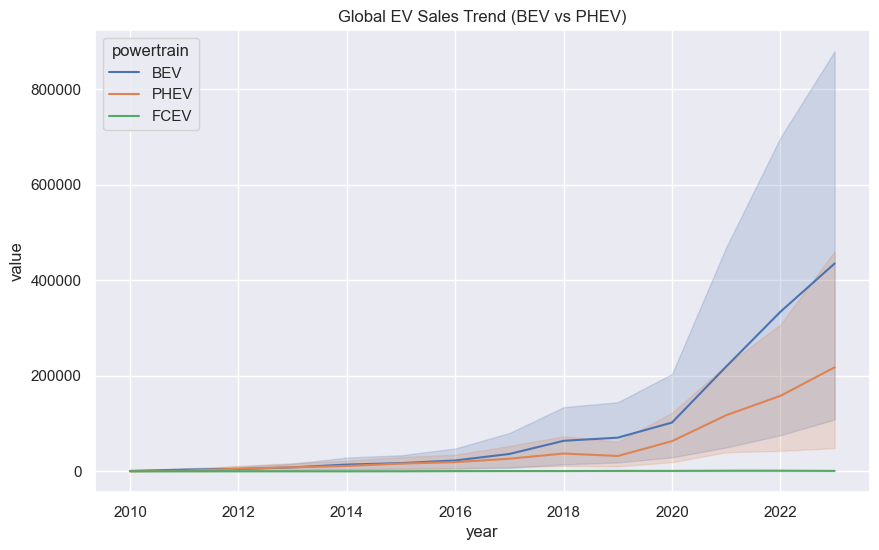

In [66]:
# Filter sales only 
df_sales = df[(df['parameter']== 'EV sales') & (df['unit'] == 'Vehicles')]

plt.figure(figsize=(10,6))
sns.lineplot(data=df_sales,
             x = 'year', y = 'value', hue = 'powertrain')
plt.title('Global EV Sales Trend (BEV vs PHEV)')
plt.show()

### Global Transition: BEV vs. PHEV Stock Accumulation

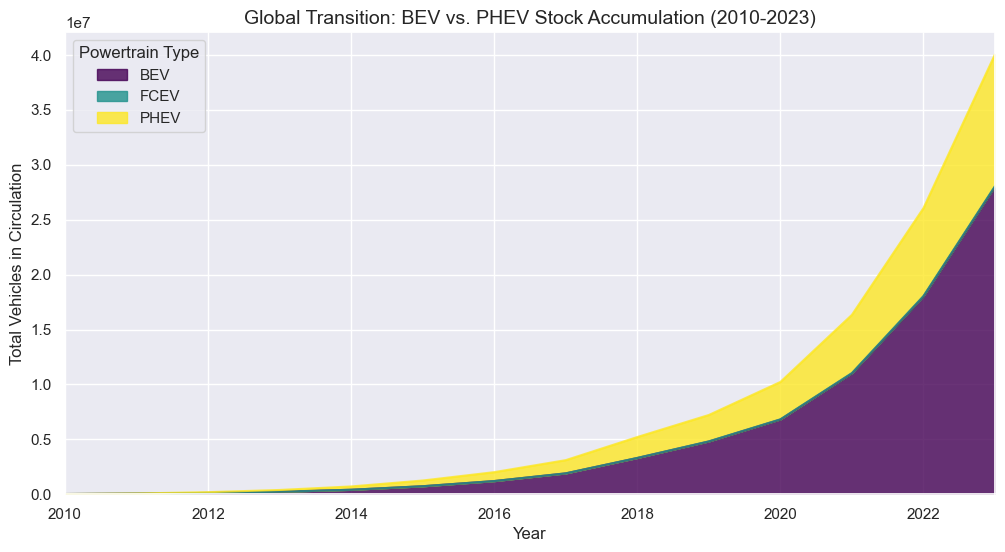

In [67]:
# Prepare data for stacked area chart
stock_growth = df[(df['region'] == 'World') & 
                  (df['parameter'] == 'EV stock') & 
                  (df['unit'] == 'Vehicles')].pivot(index='year', columns='powertrain', values='value')

stock_growth.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.8, colormap='viridis')
plt.title('Global Transition: BEV vs. PHEV Stock Accumulation (2010-2023)', fontsize=14)
plt.ylabel('Total Vehicles in Circulation')
plt.xlabel('Year')
plt.legend(title='Powertrain Type')
plt.show()

### EV Market Share Penetration (%) Across Key Regions

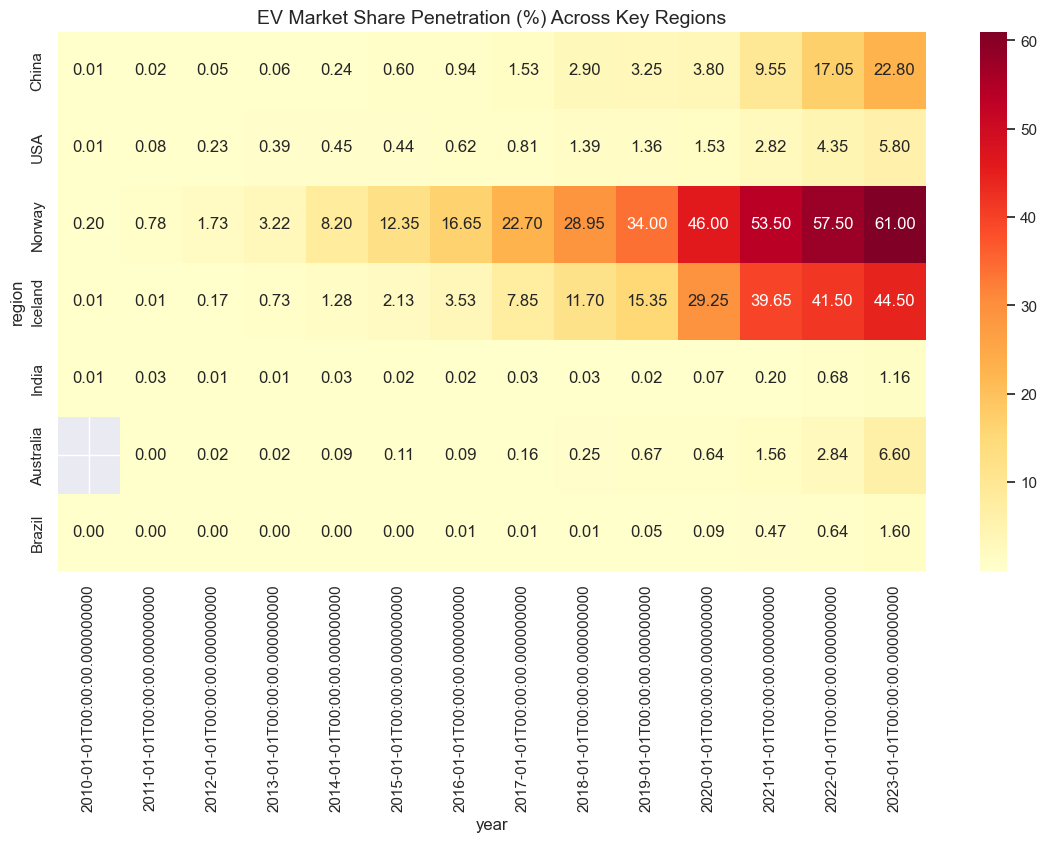

In [68]:
# Filter for market share percentage
shares_df = df[(df['unit'] == 'percent') & (df['parameter'].str.contains('share'))]
pivot_shares = shares_df.pivot_table(index='region', columns='year', values='value')

# Selecting a subset of diverse regions for clarity
target_regions = ['China', 'USA', 'Norway', 'Iceland', 'India', 'Australia', 'Brazil']
pivot_subset = pivot_shares.loc[target_regions]

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_subset, annot=True, cmap='YlOrRd', fmt=".2f")
plt.title('EV Market Share Penetration (%) Across Key Regions', fontsize=14)
plt.show()

### EV Sales Trends by Transport Mode (Cars vs. Vans vs. Buses)

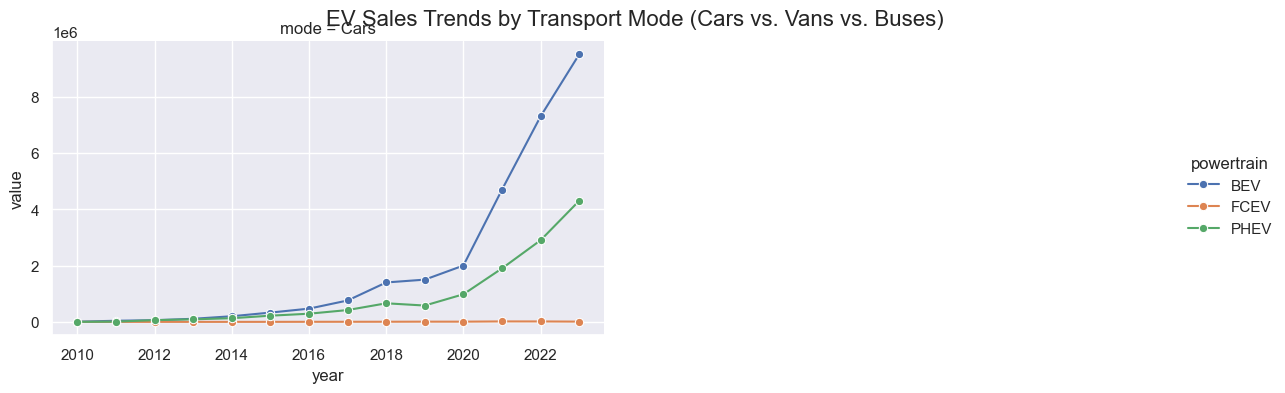

In [69]:
# Filter for global data across different transport modes
modes_df = df[(df['region'] == 'World') & (df['unit'] == 'Vehicles') & (df['parameter'] == 'EV sales')]

g = sns.FacetGrid(modes_df, col="mode", hue="powertrain", col_wrap=2, height=4, aspect=1.5)
g.map(sns.lineplot, "year", "value", marker="o")
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('EV Sales Trends by Transport Mode (Cars vs. Vans vs. Buses)', fontsize=16)
plt.show()

### Distribution of EV Sales Values (Identifying Regional Outliers)

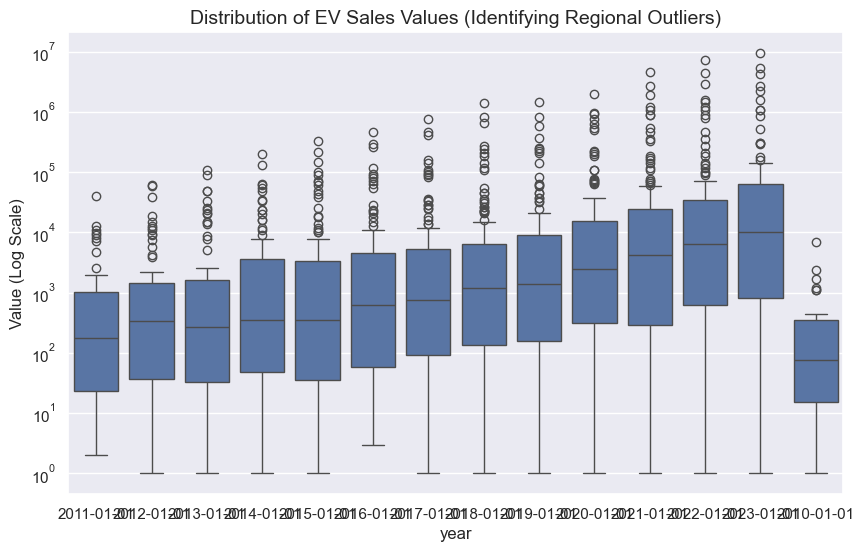

In [70]:
plt.figure(figsize=(10, 6))
# Filter for sales vehicles to avoid mixing percentages
sns.boxplot(data=df[(df['unit'] == 'Vehicles') & (df['parameter'] == 'EV sales')], x='year', y='value')
plt.yscale('log') # Log scale because China/World values are massive
plt.title('Distribution of EV Sales Values (Identifying Regional Outliers)', fontsize=14)
plt.ylabel('Value (Log Scale)')
plt.show()

### EV Market Penetration S-Curve by Region

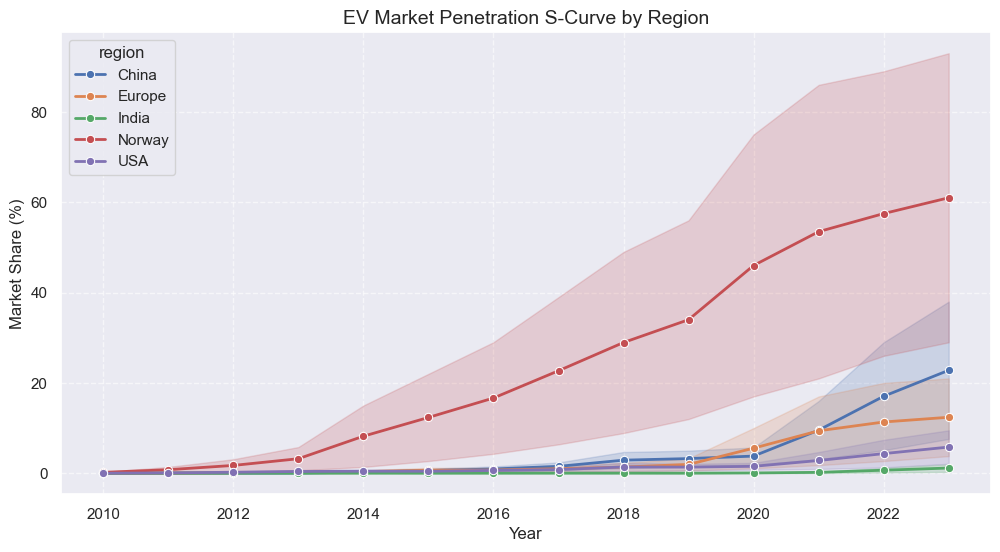

In [71]:
# Filter for market share percentages
df_penetration = df[(df['unit'] == 'percent') & (df['parameter'].str.contains('share', case=False))]

plt.figure(figsize=(12, 6))
# Focus on specific high-growth regions for a cleaner visual
selected_regions = ['China', 'USA', 'Norway', 'India', 'Europe']
sns.lineplot(data=df_penetration[df_penetration['region'].isin(selected_regions)], 
             x='year', y='value', hue='region', marker='o', linewidth=2)

plt.title('EV Market Penetration S-Curve by Region', fontsize=14)
plt.ylabel('Market Share (%)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Year-over-Year Global Sales Growth Velocity

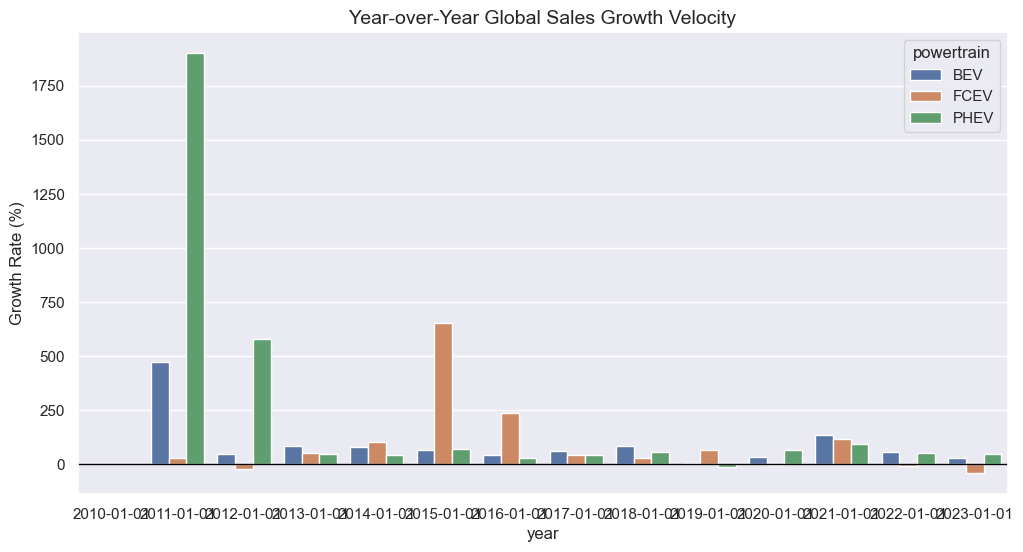

In [72]:
# Filter for sales in vehicles
df_growth = df[(df['parameter'] == 'EV sales') & (df['unit'] == 'Vehicles')].copy()

# Calculate Percentage Change per region/powertrain
df_growth = df_growth.sort_values(['region', 'powertrain', 'year'])
df_growth['yoy_growth'] = df_growth.groupby(['region', 'powertrain'])['value'].pct_change() * 100

#: Plotting the growth velocity for the 'World'
plt.figure(figsize=(12, 6))
sns.barplot(data=df_growth[df_growth['region'] == 'World'], x='year', y='yoy_growth', hue='powertrain')

plt.title('Year-over-Year Global Sales Growth Velocity', fontsize=14)
plt.ylabel('Growth Rate (%)')
plt.axhline(0, color='black', lw=1) # Baseline
plt.show()

# Hadi Al-Hajji - 8MA2